In [3]:
import os
from dotenv import load_dotenv
from pydantic import SecretStr

load_dotenv(override=True)

OPENAI_API_KEY: SecretStr = SecretStr(os.getenv("OPENAI_API_KEY", ""))
OPENAI_API_URL: str = os.getenv("OPENAI_API_URL", "")
OPENAI_MODEL: str = "qwen/qwen3.6-27b"

TAVILY_API_KEY: str = os.getenv("TAVILY_API_KEY", "")

In [7]:
from typing import Literal
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


# Web search tool
def web_search(
    query: str,
    max_results: int = 5,
    topic: Literal['general', 'news', 'finance'] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query=query,
        max_results=max_results,
        topic=topic,
        include_raw_content=include_raw_content,
    )

In [10]:
result = web_search(query="Deep Agents",max_results=3)
result

{'query': 'Deep Agents',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.langchain.com/deep-agents',
   'title': 'LangChain Deep Agents: Build Agents for Complex, Multi-Step Tasks',
   'content': '# Build agents for complex, multi-step tasks. Deep Agents is an open source agent harness built for long-running tasks. It handles planning, context management, and multi-agent orchestration for complex work like research and coding. ## Why use Deep Agents? Agents are taking on increasingly complex work over long time horizons, like research, coding, and multi-step workflows. Context management is critical for long-running agents, and hard to get right. Deep Agents is available as an SDK and CLI, so you can use it in your codebase or run it directly in your terminal. #### Deep Agents. Learn about the fundamental characteristics of Deep Agents - including planning, memory, and subagents - and how to implement your own Deep Agent for complex, long

In [11]:
from langchain_openai import ChatOpenAI

LLM = ChatOpenAI(
    base_url=OPENAI_API_URL,
    api_key=OPENAI_API_KEY,
    model=OPENAI_MODEL,
    streaming=False,
    reasoning_effort=None,
)

LLM

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9', 'langchain-openai': '1.3.2'}}, output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x7a402cd714f0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7a402ccfe480>, root_client=<openai.OpenAI object at 0x7a402cdea360>, root_async_client=<openai.AsyncOpenAI object at 0x7a402ccfeae0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.groq.com/openai/v1', openai_proxy=None, stream_chunk_timeout=120.0)

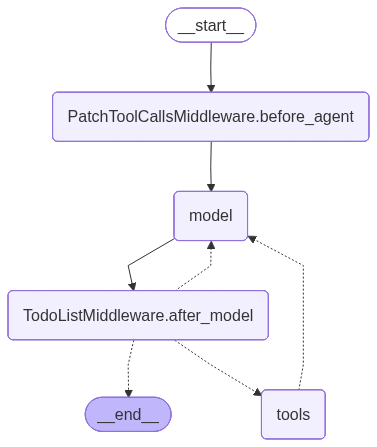

In [12]:
from deepagents import create_deep_agent

deep_agent = create_deep_agent(
    model=LLM,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deep_agent

In [13]:
result = deep_agent.invoke(input={"messages": [{"role": "user", "content": "What is DeepAgents?"}]})
result

{'messages': [HumanMessage(content='What is DeepAgents?', additional_kwargs={}, response_metadata={}, id='ce8092a1-dbcd-4cca-a941-787c903d9e3e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 6325, 'total_tokens': 6427, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 71, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.047969819, 'prompt_time': 0.438945511, 'completion_time': 0.193751523, 'total_time': 0.632697034}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_2f860a3fc2', 'id': 'chatcmpl-3e892fc8-07e8-40e3-831e-10ef4e05e3aa', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed19c-812c-7d41-8d34-669ea6144da8-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'DeepAgents platform framework'}, 'id': '7z94wzxqk'

In [14]:
from IPython.display import Markdown, display

display(Markdown(result["messages"][-1].content))

**DeepAgents** is an open-source agent harness by **LangChain** designed for building long-running, complex, multi-step AI agents.

It sits on top of LangChain and LangGraph and provides a more opinionated, batteries-included framework compared to the lower-level `create_agent` primitive. Key capabilities include:

- **Planning** — Built-in todo/task list management for breaking down and tracking complex objectives
- **Context management** — Automatically offloads large content to a virtual filesystem to avoid bloating the context window
- **Sub-agent spawning** — Can delegate tasks to isolated child agents that run independently and return structured results
- **Filesystem tools** — Includes a mock filesystem with read, write, search, and listing capabilities
- **Skill system** — Pluggable skills for extending agent capabilities

It's intended for agents that need to operate over long time horizons — research, coding, multi-step workflows — rather than simple Q&A. It can be used as both an SDK (`pip install deepagents`) and a CLI.

The architecture is composable with LangGraph: any `CompiledStateGraph` can be passed in as a sub-agent, so custom orchestration integrates alongside DeepAgents' defaults.

### State Backend

In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

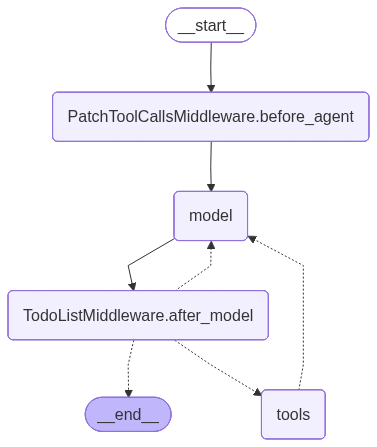

In [2]:
import os
from deepagents import create_deep_agent
from deepagents.backends import StateBackend

agent = create_deep_agent(model="groq:qwen/qwen3.6-27b", backend=StateBackend())
agent

In [3]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": """Create a file at /notes/todo.txt with exactly this content: \n
                            1. Record video\n2. Edit video\n3. Upload video""",
            }
        ]
    }
)
result

{'messages': [HumanMessage(content='Create a file at /notes/todo.txt with exactly this content: \n\n                            1. Record video\n2. Edit video\n3. Upload video', additional_kwargs={}, response_metadata={}, id='b30a3579-2a36-4f7d-92d2-5b51bd4d9cca'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants me to create a file with specific content, including leading spaces on the first line.\n', 'tool_calls': [{'id': 'a1ed39vz1', 'function': {'arguments': '{"content":"1. Record video\\n2. Edit video\\n3. Upload video","file_path":"/notes/todo.txt"}', 'name': 'write_file'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 6229, 'total_tokens': 6309, 'completion_time': 0.177569801, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.840248839, 'prompt_tokens_details': None, 'queue_time': 4.805645175, 'total_time': 1.01781864}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint'

In [4]:
result["messages"][-1].content

'Created `/notes/todo.txt` with the specified content.'

In [5]:
files = result.get("files", {})

if files:
    print(f"State backend is working - {len(files)} file(s) in state:")

    for path, content in files.items():
        print(f"\n {path}\n {'-'*40}\n{content}")

else:
    print("No files found in the state.")

State backend is working - 1 file(s) in state:

 /notes/todo.txt
 ----------------------------------------
{'content': '1. Record video\n2. Edit video\n3. Upload video', 'encoding': 'utf-8', 'created_at': '2026-06-17T03:03:00.408303+00:00', 'modified_at': '2026-06-17T03:03:00.408303+00:00'}


In [ ]:
result = agent.invoke(
    {
        "messages": result["messages"]
        + [
            {"role": "user", "content": "Tell me my todos from the todo.txt file"},
        ],
        "files": result.get("files", {}),
    } # type: ignore
)
result

{'messages': [HumanMessage(content='Create a file at /notes/todo.txt with exactly this content: \n\n                            1. Record video\n2. Edit video\n3. Upload video', additional_kwargs={}, response_metadata={}, id='b30a3579-2a36-4f7d-92d2-5b51bd4d9cca'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants me to create a file with specific content, including leading spaces on the first line.\n', 'tool_calls': [{'id': 'a1ed39vz1', 'function': {'arguments': '{"content":"1. Record video\\n2. Edit video\\n3. Upload video","file_path":"/notes/todo.txt"}', 'name': 'write_file'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 6229, 'total_tokens': 6309, 'completion_time': 0.177569801, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.840248839, 'prompt_tokens_details': None, 'queue_time': 4.805645175, 'total_time': 1.01781864}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint'

In [8]:
result["messages"][-1].content

'Your todos:\n\n1. Record video\n2. Edit video\n3. Upload video'